# 05 — Review the final 153-event catalogue waveforms

This notebook is the waveform-review stage of the Falcon 9 workflow. It
does **not** reconstruct or redefine the event catalogue. Notebook 04 is
authoritative for event association, the 0.040 s association window,
targeted candidate decisions, and final event numbering.

This notebook:

1. loads the final 153-event catalogue and its accepted pick assignments;
2. verifies that every final event is represented consistently in the
   Notebook 04 products;
3. uses the six-channel response-corrected Stream for seismic review;
4. uses the baseline-corrected pressure Stream for aligned pressure traces
   and stacks;
5. merges the standardized S03 waveform-quality measurements when present;
6. generates paired unshifted and travel-time-aligned figures using final
   event numbers; and
7. reviews excluded Notebook 04 candidates separately so they cannot be
   mistaken for retained events.

The legacy 157-event catalogue is no longer an input to this notebook.


## Scientific authority and data flow

```text
Notebook 04
    ├── 04_final_153_event_catalogue.csv          authoritative events
    ├── 04_reduced_time_pick_assignments.csv      authoritative picks
    └── 04_event_catalogue_decisions.csv          retained/excluded audit

Notebook 02
    └── baseline-corrected pressure MiniSEED      pressure review/stacking

S03 (optional)
    └── S03_event_waveform_quality.csv            standardized quality metrics

Notebook 05
    └── figures, gallery, manifests, and audit products only
```

Event existence is never determined here from SNR, stack amplitude, or
beamforming. Those quantities describe waveform quality after the
catalogue has been fixed.


## 1. Imports and project paths


In [1]:
from __future__ import annotations

from collections.abc import Mapping
from pathlib import Path
import html
import json
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from obspy import Stream, Trace, UTCDateTime, read

project_root = Path.cwd().resolve()
if project_root.name == "notebooks2":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from modules import project_config as config

pd.set_option("display.max_columns", 100)
plt.rcParams.update({
    "font.size": 8.5,
    "axes.titlesize": 9.5,
    "axes.labelsize": 8.5,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "legend.fontsize": 7.5,
    "figure.dpi": 120,
})


## 2. Inputs, outputs, and review settings


In [2]:
ANALYSIS_CONFIG_FILE = config.OUTPUT_DIR / "02_analysis_configuration.json"
WEATHER_SUMMARY_FILE = config.OUTPUT_DIR / "03_weather_acoustic_summary.csv"
FINAL_CATALOGUE_FILE = config.OUTPUT_DIR / "04_final_153_event_catalogue.csv"
PICK_ASSIGNMENTS_FILE = config.OUTPUT_DIR / "04_reduced_time_pick_assignments.csv"
CATALOGUE_DECISIONS_FILE = config.OUTPUT_DIR / "04_event_catalogue_decisions.csv"


S03_QUALITY_CANDIDATES = [
    config.OUTPUT_DIR
    / "S03_infrapy_bartlett_validation"
    / "S03_event_waveform_quality.csv",
    config.OUTPUT_DIR
    / "S03_infrapy_bartlett_validation_cont"
    / "S03_event_waveform_quality.csv",
]

REVIEW_OUTPUT_DIR = config.OUTPUT_DIR / "05_event_waveform_review"
REVIEW_FIGURE_DIR = config.FIGURE_DIR / "05_event_waveform_review"
RETAINED_UNSHIFTED_DIR = REVIEW_FIGURE_DIR / "retained_unshifted"
RETAINED_SHIFTED_DIR = REVIEW_FIGURE_DIR / "retained_shifted"
EXCLUDED_AUDIT_DIR = REVIEW_FIGURE_DIR / "excluded_candidates"

for directory in [
    REVIEW_OUTPUT_DIR,
    REVIEW_FIGURE_DIR,
    RETAINED_UNSHIFTED_DIR,
    RETAINED_SHIFTED_DIR,
    EXCLUDED_AUDIT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

EXPECTED_FINAL_EVENT_COUNT = 153
UNSHIFTED_PRE_S = 0.12
UNSHIFTED_POST_S = 0.45
SHIFTED_PRE_S = 0.08
SHIFTED_POST_S = 0.25

PICK_MARKER_SIZE = 52
PICK_MARKER_COLOR = "tab:orange"
PICK_EDGE_COLOR = "black"

WRITE_RETAINED_EVENT_PNGS = True
WRITE_EXCLUDED_AUDIT_PNGS = True
WRITE_HTML_GALLERY = True
PREVIEW_FINAL_EVENT_NUMBER = 1


## 3. Load authoritative catalogue products and Streams


In [3]:
for required_file in [
    ANALYSIS_CONFIG_FILE,
    WEATHER_SUMMARY_FILE,
    FINAL_CATALOGUE_FILE,
    PICK_ASSIGNMENTS_FILE,
    CATALOGUE_DECISIONS_FILE,
]:
    if not required_file.exists():
        raise FileNotFoundError(required_file)

analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())

baseline_products = analysis_config.get("baseline_removed_streams", {})
BASELINE_MSEED_FILE = Path(
    baseline_products.get(
        "mseed",
        config.DERIVED_DIR
        / "bchh_corrected_moving_median_baseline_removed.mseed",
    )
).expanduser()
BASELINE_PICKLE_FILE = Path(
    baseline_products.get(
        "pickle",
        config.DERIVED_DIR
        / "bchh_corrected_moving_median_baseline_removed.pkl",
    )
).expanduser()
geometry_file = Path(analysis_config["geometry_file"]).expanduser()
review_stream_file = Path(analysis_config["stream_file"]).expanduser()
for required_file in [geometry_file, review_stream_file]:
    if not required_file.exists():
        raise FileNotFoundError(required_file)

final_catalogue = pd.read_csv(FINAL_CATALOGUE_FILE)
pick_assignments = pd.read_csv(PICK_ASSIGNMENTS_FILE)
catalogue_decisions = pd.read_csv(CATALOGUE_DECISIONS_FILE)
geometry = pd.read_csv(geometry_file)
weather_summary = pd.read_csv(WEATHER_SUMMARY_FILE)
if len(weather_summary) != 1:
    raise ValueError("Expected exactly one weather-summary row")

review_stream = read(str(review_stream_file), format="PICKLE")
if BASELINE_MSEED_FILE.exists():
    baseline_pressure_file = BASELINE_MSEED_FILE
    baseline_pressure_stream = read(
        str(baseline_pressure_file), format="MSEED"
    )
elif BASELINE_PICKLE_FILE.exists():
    baseline_pressure_file = BASELINE_PICKLE_FILE
    baseline_pressure_stream = read(
        str(baseline_pressure_file), format="PICKLE"
    )
else:
    raise FileNotFoundError(
        "Run Notebook 02 to create the baseline-corrected pressure Stream"
    )

def normalized_units(value: object) -> str:
    return str(value).strip().lower().replace(" ", "")


review_channels = [trace.stats.channel for trace in review_stream]
if len(review_channels) != len(set(review_channels)):
    raise ValueError(f"Duplicate review Stream channels: {review_channels}")

review_units = {
    trace.stats.channel: normalized_units(trace.stats.get("units"))
    for trace in review_stream
}
configured_pressure_channels = analysis_config.get("pressure_channels", [])
pressure_channels = [
    channel
    for channel in configured_pressure_channels
    if channel in review_channels
]
if not pressure_channels:
    pressure_channels = [
        channel
        for channel in review_channels
        if review_units[channel] in {"pa", "pascal", "pascals"}
    ]

configured_seismic_channels = analysis_config.get("seismic_channels", [])
seismic_channels = [
    channel
    for channel in configured_seismic_channels
    if channel in review_channels
]
if not seismic_channels:
    seismic_channels = [
        channel
        for channel in review_channels
        if review_units[channel] in {"m/s", "m/s**1", "m*s^-1"}
    ]

component_order = {"Z": 0, "N": 1, "E": 2}
seismic_channels = sorted(
    seismic_channels,
    key=lambda channel: (
        component_order.get(channel[-1].upper(), 99),
        channel,
    ),
)

if len(pressure_channels) != 3 or len(seismic_channels) != 3:
    raise ValueError(
        "Review layout expects three pressure and three seismic channels; "
        f"pressure={pressure_channels}, seismic={seismic_channels}"
    )

baseline_by_channel = {
    trace.stats.channel: trace
    for trace in baseline_pressure_stream
}
missing_baseline_channels = set(pressure_channels) - set(baseline_by_channel)
if missing_baseline_channels:
    raise KeyError(
        "Baseline Stream lacks pressure channels: "
        f"{sorted(missing_baseline_channels)}"
    )
baseline_pressure_stream = Stream([
    baseline_by_channel[channel].copy()
    for channel in pressure_channels
])

reference_channel = str(analysis_config["infrasound_reference_channel"])
if reference_channel not in pressure_channels:
    raise ValueError(
        f"Configured reference channel {reference_channel} is not pressure"
    )

print("Final catalogue:", len(final_catalogue), "events")
print("Review Stream:", review_stream_file)
print("Baseline pressure Stream:", baseline_pressure_file)
print("Pressure channels:", pressure_channels)
print("Seismic channels:", seismic_channels)


Final catalogue: 153 events
Review Stream: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/02_bchh_corrected_analysis_window.pkl
Baseline pressure Stream: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/derived2/bchh_corrected_moving_median_baseline_removed.mseed
Pressure channels: ['DD1', 'DD2', 'DD3']
Seismic channels: ['DHZ', 'DHN', 'DHE']


## 4. Validate the Notebook 04 catalogue handoff


In [4]:
required_catalogue_columns = {
    "final_event_number",
    "reconstructed_event_number",
    "reduced_event_epoch_s",
    "corrected_pick_span_s",
    "channels",
    "pick_indices",
}
missing = required_catalogue_columns.difference(final_catalogue.columns)
if missing:
    raise KeyError(f"Final catalogue lacks columns: {sorted(missing)}")

required_assignment_columns = {
    "pickIndex",
    "arrivalTimeEpochS",
    "association_channel",
    "reduced_pick_epoch_s",
    "reconstructed_event_number",
    "association_status",
}
missing = required_assignment_columns.difference(pick_assignments.columns)
if missing:
    raise KeyError(f"Pick assignments lack columns: {sorted(missing)}")

if len(final_catalogue) != EXPECTED_FINAL_EVENT_COUNT:
    raise RuntimeError(
        f"Expected {EXPECTED_FINAL_EVENT_COUNT} final events; "
        f"found {len(final_catalogue)}"
    )
if not final_catalogue["final_event_number"].is_unique:
    raise ValueError("final_event_number is not unique")
expected_numbers = np.arange(1, len(final_catalogue) + 1)
if not np.array_equal(
    final_catalogue["final_event_number"].astype(int).to_numpy(),
    expected_numbers,
):
    raise ValueError("Final event numbers are not consecutive from 1")

retained_reconstructed_numbers = set(
    final_catalogue["reconstructed_event_number"].astype(int)
)
retained_assignments = pick_assignments.loc[
    pick_assignments["association_status"].eq("associated")
    & pick_assignments["reconstructed_event_number"].isin(
        retained_reconstructed_numbers
    )
].copy()

event_number_map = final_catalogue.set_index(
    "reconstructed_event_number"
)["final_event_number"]
retained_assignments["final_event_number"] = (
    retained_assignments["reconstructed_event_number"]
    .map(event_number_map)
    .astype(int)
)

assignment_support = (
    retained_assignments
    .groupby("final_event_number")
    .agg(
        assigned_pick_count=("pickIndex", "size"),
        assigned_channel_count=("association_channel", "nunique"),
        assigned_channels=(
            "association_channel",
            lambda values: ",".join(sorted(set(values))),
        ),
    )
    .reset_index()
)
handoff_audit = final_catalogue.merge(
    assignment_support,
    on="final_event_number",
    how="left",
    validate="one_to_one",
)
if handoff_audit["assigned_channel_count"].isna().any():
    raise RuntimeError("One or more final events have no assigned picks")
if (handoff_audit["assigned_channel_count"] < 2).any():
    raise RuntimeError("A final event has fewer than two assigned channels")
if not handoff_audit["channels"].eq(
    handoff_audit["assigned_channels"]
).all():
    raise RuntimeError("Catalogue channel lists disagree with assignments")

excluded_candidates = catalogue_decisions.loc[
    ~catalogue_decisions["catalogue_decision"].eq("retain")
].copy()
excluded_numbers = set(
    excluded_candidates["reconstructed_event_number"].astype(int)
)
excluded_assignments = pick_assignments.loc[
    pick_assignments["association_status"].eq("associated")
    & pick_assignments["reconstructed_event_number"].isin(excluded_numbers)
].copy()

print("Retained events:", len(final_catalogue))
print("Retained assigned picks:", len(retained_assignments))
print("Excluded candidates retained for audit:", len(excluded_candidates))
display(
    handoff_audit[
        [
            "final_event_number",
            "reconstructed_event_number",
            "reduced_event_time",
            "assigned_pick_count",
            "assigned_channels",
        ]
    ].head()
)
display(
    excluded_candidates[
        [
            "reconstructed_event_number",
            "reduced_event_time",
            "channels",
            "catalogue_decision",
            "decision_basis",
        ]
    ]
)


Retained events: 153
Retained assigned picks: 369
Excluded candidates retained for audit: 1


,final_event_number,reconstructed_event_number,reduced_event_time,assigned_pick_count,assigned_channels
0,1,1,2016-09-01 13:07:15.927133560+00:00,3,"DD1,DD2,DD3"
1,2,2,2016-09-01 13:07:16.057133436+00:00,3,"DD1,DD2,DD3"
2,3,3,2016-09-01 13:07:16.255000114+00:00,3,"DD1,DD2,DD3"
3,4,4,2016-09-01 13:07:16.447066784+00:00,2,"DD2,DD3"
4,5,5,2016-09-01 13:07:16.799566746+00:00,2,"DD2,DD3"


,reconstructed_event_number,reduced_event_time,channels,catalogue_decision,decision_basis
147,148,2016-09-01 13:24:50.830946684+00:00,"DD1,DD2",exclude_ambiguous,DD1-DD2 only; no DD3 pick or coherent DD3 coun...


## 5. Geometry, travel-time shifts, and optional S03 quality metrics


In [5]:
geometry_by_channel = (
    geometry.drop_duplicates("channel").set_index("channel")
)
missing_geometry = set(pressure_channels) - set(geometry_by_channel.index)
if missing_geometry:
    raise KeyError(
        f"Geometry lacks pressure channels: {sorted(missing_geometry)}"
    )

effective_sound_speed_mps = float(
    weather_summary.iloc[0]["effective_sound_speed_mps"]
)
reference_distance_m = float(
    geometry_by_channel.at[reference_channel, "distance_m"]
)
differential_delays_s = {
    channel: (
        float(geometry_by_channel.at[channel, "distance_m"])
        - reference_distance_m
    ) / effective_sound_speed_mps
    for channel in pressure_channels
}

assignment_delay_table = (
    pick_assignments[
        ["association_channel", "travel_time_correction_s"]
    ]
    .dropna()
    .drop_duplicates()
    .set_index("association_channel")["travel_time_correction_s"]
)
for channel, delay_s in differential_delays_s.items():
    if channel in assignment_delay_table.index:
        if not np.isclose(
            delay_s,
            float(assignment_delay_table.loc[channel]),
            atol=1.0e-9,
        ):
            raise RuntimeError(
                f"Travel-time correction mismatch for {channel}"
            )

quality_file = next(
    (path for path in S03_QUALITY_CANDIDATES if path.exists()),
    None,
)
if quality_file is not None:
    waveform_quality = pd.read_csv(quality_file)
    if len(waveform_quality) != len(final_catalogue):
        raise RuntimeError(
            "S03 quality table does not contain one row per final event"
        )
    review_catalogue = final_catalogue.merge(
        waveform_quality,
        on="final_event_number",
        how="left",
        validate="one_to_one",
    )
    print("Loaded standardized S03 quality metrics:", quality_file)
else:
    waveform_quality = pd.DataFrame()
    review_catalogue = final_catalogue.copy()
    print("S03 quality table not found; gallery will omit quality metrics")

display(
    pd.DataFrame({
        "channel": pressure_channels,
        "distance_m": [
            float(geometry_by_channel.at[channel, "distance_m"])
            for channel in pressure_channels
        ],
        "delay_relative_to_reference_s": [
            differential_delays_s[channel]
            for channel in pressure_channels
        ],
    })
)


Loaded standardized S03 quality metrics: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/S03_infrapy_bartlett_validation_cont/S03_event_waveform_quality.csv


,channel,distance_m,delay_relative_to_reference_s
0,DD1,1439.963831,0.090107
1,DD2,1408.338457,0.000000
2,DD3,1412.854330,0.012867


## 6. Waveform-review helpers

The pressure panels and stacks use the Notebook 02 baseline-corrected
Stream. Seismic panels use the response-corrected six-channel Stream.
Pressure traces are sampled directly on a common reference-time grid
after applying the predicted differential delays. This avoids the
all-NaN edge samples produced by trimming independently shifted traces.

Notebook 05 does not define a competing SNR. When available, the figures
display the standardized S03 robust peak SNR, RMS SNR, DD2--DD3
correlation, and residual lag.


In [6]:
def select_one_trace(stream: Stream, channel: str) -> Trace:
    matches = stream.select(channel=channel)
    if len(matches) != 1:
        raise ValueError(
            f"Expected one trace for {channel}; found {len(matches)}"
        )
    return matches[0]


def component_label(channel: str) -> str:
    return {
        "Z": "Vertical",
        "N": "North",
        "E": "East",
    }.get(channel[-1].upper(), channel)


def sample_trace_at_epochs(
    trace: Trace,
    epoch_times_s: np.ndarray,
) -> np.ndarray:
    sample_positions = (
        np.asarray(epoch_times_s, dtype=float)
        - float(trace.stats.starttime.timestamp)
    ) * float(trace.stats.sampling_rate)
    return np.interp(
        sample_positions,
        np.arange(trace.stats.npts, dtype=float),
        np.asarray(trace.data, dtype=float),
        left=np.nan,
        right=np.nan,
    )


def event_picks(final_event_number: int) -> pd.DataFrame:
    return retained_assignments.loc[
        retained_assignments["final_event_number"].eq(
            int(final_event_number)
        )
    ].copy()


def quality_text(event: pd.Series) -> str:
    if "s03_robust_stack_peak_snr" not in event.index:
        return "S03 quality metrics unavailable"
    return (
        f"S03 peak SNR {event['s03_robust_stack_peak_snr']:.2f}; "
        f"RMS SNR {event['s03_stack_rms_snr']:.2f}; "
        f"pair correlation {event['s03_pair_best_correlation']:.3f}; "
        f"residual lag {event['s03_pair_residual_lag_s']:+.3f} s"
    )


def aligned_pressure_arrays(
    center_epoch_s: float,
    start_relative_s: float,
    end_relative_s: float,
) -> tuple[np.ndarray, dict[str, np.ndarray]]:
    sampling_rates = {
        float(trace.stats.sampling_rate)
        for trace in baseline_pressure_stream
    }
    if len(sampling_rates) != 1:
        raise ValueError(
            f"Mixed baseline sampling rates: {sampling_rates}"
        )
    sampling_rate_hz = sampling_rates.pop()
    relative_time_s = np.arange(
        start_relative_s,
        end_relative_s + 0.5 / sampling_rate_hz,
        1.0 / sampling_rate_hz,
    )
    arrays = {}
    for channel in pressure_channels:
        trace = select_one_trace(baseline_pressure_stream, channel)
        observed_epoch_s = (
            center_epoch_s
            + relative_time_s
            + differential_delays_s[channel]
        )
        arrays[channel] = sample_trace_at_epochs(
            trace, observed_epoch_s
        )
    matrix = np.vstack([arrays[channel] for channel in pressure_channels])
    if not np.isfinite(matrix).all():
        raise RuntimeError(
            "Requested aligned pressure window exceeds common coverage"
        )
    return relative_time_s, arrays


In [7]:
def build_unshifted_figure(
    event: pd.Series,
    picks: pd.DataFrame,
    *,
    retained: bool,
):
    center_epoch_s = float(event["reduced_event_epoch_s"])
    observed_start_s = float(picks["arrivalTimeEpochS"].min())
    observed_end_s = float(picks["arrivalTimeEpochS"].max())
    plot_start_s = min(
        center_epoch_s - UNSHIFTED_PRE_S,
        observed_start_s - 0.04,
    )
    plot_end_s = max(
        center_epoch_s + UNSHIFTED_POST_S,
        observed_end_s + 0.20,
    )
    relative_time_s = np.arange(
        plot_start_s - center_epoch_s,
        plot_end_s - center_epoch_s + 0.002,
        1.0 / float(review_stream[0].stats.sampling_rate),
    )
    epoch_grid_s = center_epoch_s + relative_time_s

    fig = plt.figure(
        figsize=(12.0, 7.1), constrained_layout=True
    )
    grid = fig.add_gridspec(
        3, 2, width_ratios=(1.0, 1.25), wspace=0.08, hspace=0.05
    )
    seismic_axes = [fig.add_subplot(grid[i, 0]) for i in range(3)]
    pressure_axes = [fig.add_subplot(grid[i, 1]) for i in range(3)]

    seismic_arrays = {
        channel: sample_trace_at_epochs(
            select_one_trace(review_stream, channel), epoch_grid_s
        )
        for channel in seismic_channels
    }
    pressure_arrays = {
        channel: sample_trace_at_epochs(
            select_one_trace(baseline_pressure_stream, channel),
            epoch_grid_s,
        )
        for channel in pressure_channels
    }
    seismic_limit = max(
        np.nanmax(np.abs(values))
        for values in seismic_arrays.values()
    )
    pressure_limit = max(
        np.nanmax(np.abs(values))
        for values in pressure_arrays.values()
    )
    seismic_limit = max(seismic_limit * 1.08, 1.0e-12)
    pressure_limit = max(pressure_limit * 1.08, 1.0)

    axes_by_channel = {}
    for index, (axis, channel) in enumerate(
        zip(seismic_axes, seismic_channels)
    ):
        axis.plot(relative_time_s, seismic_arrays[channel], lw=0.9)
        axis.axhline(0.0, lw=0.5, alpha=0.5)
        axis.axvline(0.0, lw=1.0)
        axis.set_ylim(-seismic_limit, seismic_limit)
        axis.text(
            0.02, 0.86, component_label(channel),
            transform=axis.transAxes, fontweight="bold", va="top"
        )
        if index < 2:
            axis.tick_params(labelbottom=False)
        axis.spines[["top", "right"]].set_visible(False)

    for index, (axis, channel) in enumerate(
        zip(pressure_axes, pressure_channels)
    ):
        axis.plot(relative_time_s, pressure_arrays[channel], lw=1.0)
        axis.axhline(0.0, lw=0.5, alpha=0.5)
        axis.axvline(0.0, lw=1.0)
        axis.set_ylim(-pressure_limit, pressure_limit)
        axis.text(
            0.02, 0.86, channel,
            transform=axis.transAxes, fontweight="bold", va="top"
        )
        if index < 2:
            axis.tick_params(labelbottom=False)
        axis.spines[["top", "right"]].set_visible(False)
        axes_by_channel[channel] = axis

    for pick in picks.itertuples(index=False):
        channel = str(pick.association_channel)
        if channel not in axes_by_channel:
            continue
        axis = axes_by_channel[channel]
        trace = select_one_trace(baseline_pressure_stream, channel)
        value = sample_trace_at_epochs(
            trace, np.array([float(pick.arrivalTimeEpochS)])
        )[0]
        relative_s = float(pick.arrivalTimeEpochS) - center_epoch_s
        axis.scatter(
            [relative_s], [value], s=PICK_MARKER_SIZE,
            facecolors=PICK_MARKER_COLOR,
            edgecolors=PICK_EDGE_COLOR, linewidths=0.7, zorder=7
        )
        axis.annotate(
            str(int(pick.pickIndex)), (relative_s, value),
            xytext=(4, 6), textcoords="offset points", fontsize=6.5
        )

    for axis in seismic_axes + pressure_axes:
        axis.set_xlim(relative_time_s[0], relative_time_s[-1])
        axis.grid(axis="x", lw=0.4, alpha=0.3)
    seismic_axes[0].set_title("Ground velocity", fontweight="bold")
    pressure_axes[0].set_title(
        "Baseline-corrected acoustic pressure", fontweight="bold"
    )
    seismic_axes[1].set_ylabel("Ground velocity (m s$^{-1}$)")
    pressure_axes[1].set_ylabel("Pressure (Pa)")
    seismic_axes[-1].set_xlabel("Time relative to reduced event (s)")
    pressure_axes[-1].set_xlabel("Time relative to reduced event (s)")

    if retained:
        identity = (
            f"Final event {int(event['final_event_number']):03d}; "
            f"reconstructed event "
            f"{int(event['reconstructed_event_number']):03d}"
        )
        detail = quality_text(event)
    else:
        identity = (
            "Excluded candidate; reconstructed event "
            f"{int(event['reconstructed_event_number']):03d}"
        )
        detail = str(event["decision_basis"])
    fig.suptitle(
        f"{identity}; channels {event['channels']}; "
        f"corrected pick span {event['corrected_pick_span_s']:.3f} s\n"
        f"{detail}",
        fontweight="bold",
    )
    return fig


In [8]:
def build_shifted_figure(
    event: pd.Series,
    picks: pd.DataFrame,
    *,
    retained: bool,
):
    center_epoch_s = float(event["reduced_event_epoch_s"])
    relative_time_s, arrays = aligned_pressure_arrays(
        center_epoch_s, SHIFTED_PRE_S * -1.0, SHIFTED_POST_S
    )
    matrix = np.vstack([arrays[channel] for channel in pressure_channels])
    mean_stack = np.mean(matrix, axis=0)
    median_stack = np.median(matrix, axis=0)

    fig, axes = plt.subplots(
        5, 1, figsize=(9.8, 8.0), sharex=True,
        constrained_layout=True
    )
    pressure_limit = max(
        np.max(np.abs(matrix)),
        np.max(np.abs(mean_stack)),
        np.max(np.abs(median_stack)),
    )
    pressure_limit = max(pressure_limit * 1.08, 1.0)
    axes_by_channel = {}

    for axis, channel in zip(axes[:3], pressure_channels):
        axis.plot(relative_time_s, arrays[channel], lw=1.0)
        axis.axhline(0.0, lw=0.5, alpha=0.5)
        axis.axvline(0.0, lw=1.0)
        axis.set_ylim(-pressure_limit, pressure_limit)
        axis.text(
            0.015, 0.82,
            f"{channel}; predicted shift "
            f"{differential_delays_s[channel]:+.3f} s",
            transform=axis.transAxes, fontweight="bold", va="top"
        )
        axis.spines[["top", "right"]].set_visible(False)
        axes_by_channel[channel] = axis

    axes[3].plot(relative_time_s, mean_stack, lw=1.2)
    axes[3].axhline(0.0, lw=0.5, alpha=0.5)
    axes[3].axvline(0.0, lw=1.0)
    axes[3].set_ylim(-pressure_limit, pressure_limit)
    axes[3].text(
        0.015, 0.82, "Three-channel mean stack",
        transform=axes[3].transAxes, fontweight="bold", va="top"
    )
    axes[4].plot(relative_time_s, median_stack, lw=1.2)
    axes[4].axhline(0.0, lw=0.5, alpha=0.5)
    axes[4].axvline(0.0, lw=1.0)
    axes[4].set_ylim(-pressure_limit, pressure_limit)
    axes[4].text(
        0.015, 0.82, "Three-channel median stack",
        transform=axes[4].transAxes, fontweight="bold", va="top"
    )

    for pick in picks.itertuples(index=False):
        channel = str(pick.association_channel)
        if channel not in axes_by_channel:
            continue
        relative_s = float(pick.reduced_pick_epoch_s) - center_epoch_s
        value = np.interp(relative_s, relative_time_s, arrays[channel])
        axes_by_channel[channel].scatter(
            [relative_s], [value], s=PICK_MARKER_SIZE,
            facecolors=PICK_MARKER_COLOR,
            edgecolors=PICK_EDGE_COLOR, linewidths=0.7, zorder=7
        )
        axes_by_channel[channel].annotate(
            str(int(pick.pickIndex)), (relative_s, value),
            xytext=(4, 6), textcoords="offset points", fontsize=6.5
        )

    for axis in axes:
        axis.set_xlim(relative_time_s[0], relative_time_s[-1])
        axis.grid(axis="x", lw=0.4, alpha=0.3)
    axes[2].set_ylabel("Pressure (Pa)")
    axes[-1].set_xlabel(
        "Differential-travel-time-corrected time "
        "relative to reduced event (s)"
    )

    if retained:
        identity = f"Final event {int(event['final_event_number']):03d}"
        detail = quality_text(event)
    else:
        identity = (
            "Excluded candidate; reconstructed event "
            f"{int(event['reconstructed_event_number']):03d}"
        )
        detail = str(event["decision_basis"])
    fig.suptitle(
        f"{identity}: aligned pressure traces and stacks\n{detail}",
        fontweight="bold",
    )

    metadata = {
        "mean_stack_peak_absolute_pa": float(
            np.max(np.abs(mean_stack))
        ),
        "median_stack_peak_absolute_pa": float(
            np.max(np.abs(median_stack))
        ),
    }
    return fig, metadata


## 7. Preview one retained event


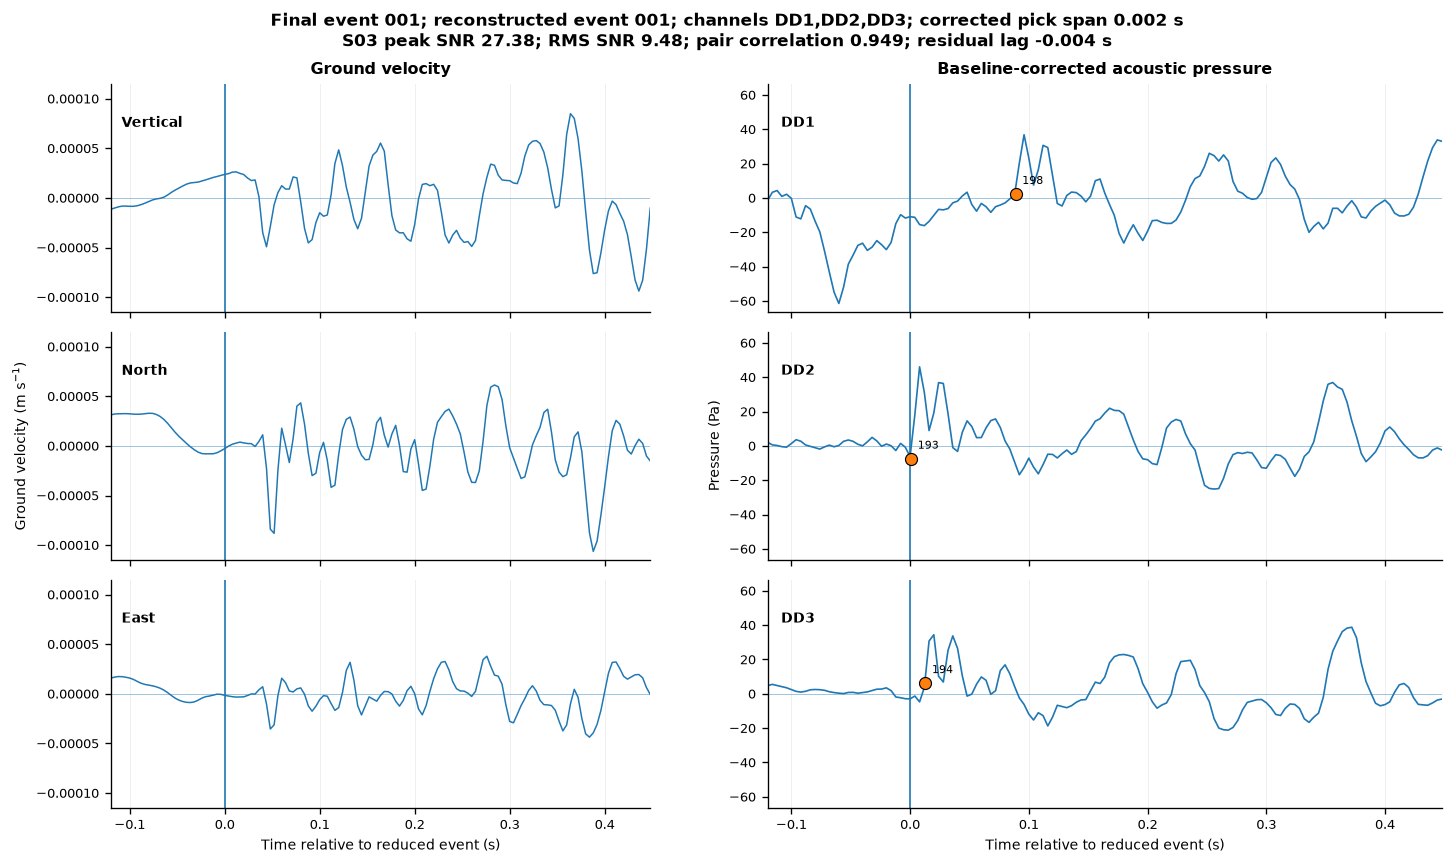

{'mean_stack_peak_absolute_pa': 37.667068869788224, 'median_stack_peak_absolute_pa': 34.682109619974405}


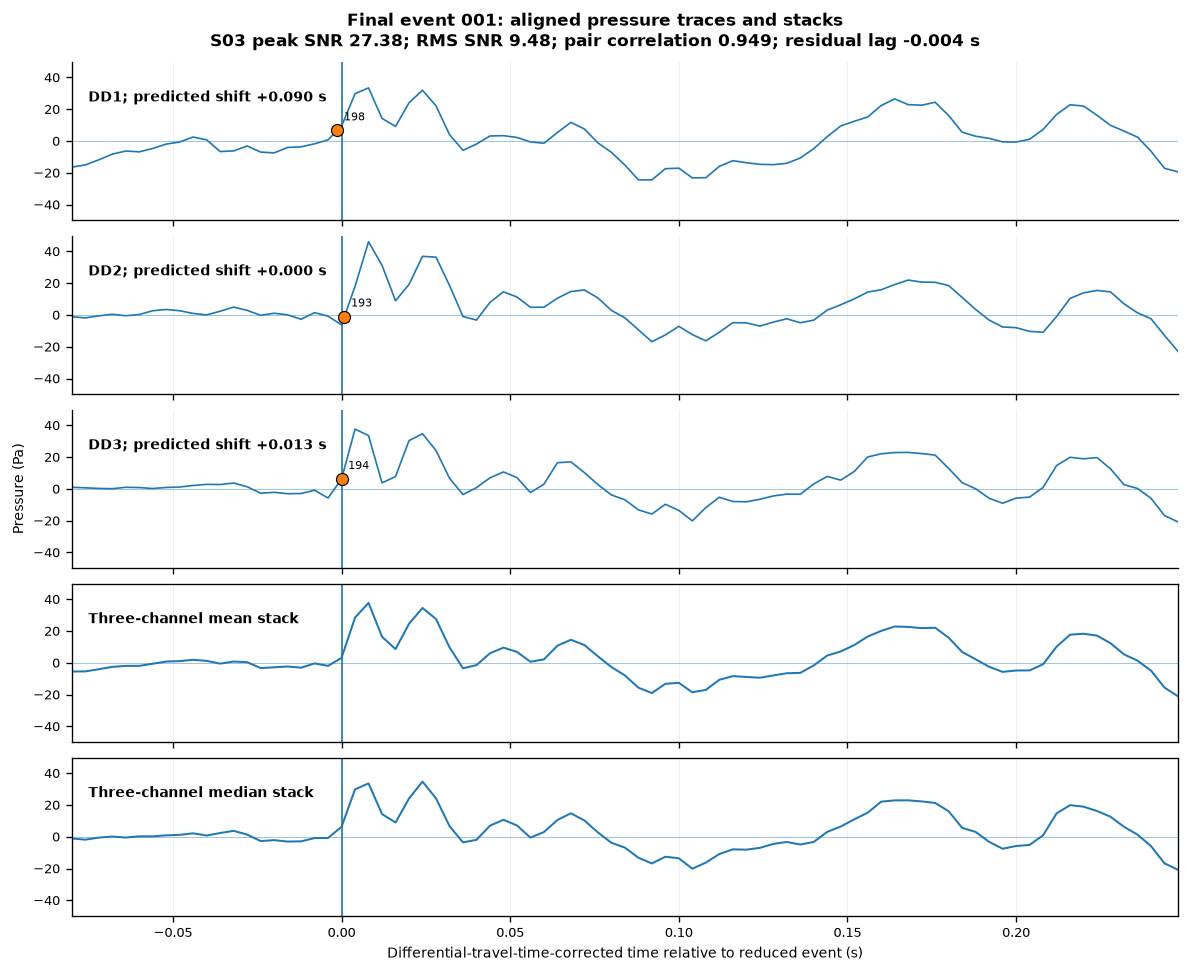

In [9]:
preview_event = review_catalogue.loc[
    review_catalogue["final_event_number"].eq(
        PREVIEW_FINAL_EVENT_NUMBER
    )
].iloc[0]
preview_picks = event_picks(PREVIEW_FINAL_EVENT_NUMBER)

preview_unshifted = build_unshifted_figure(
    preview_event, preview_picks, retained=True
)
plt.show()

preview_shifted, preview_stack_metadata = build_shifted_figure(
    preview_event, preview_picks, retained=True
)
print(preview_stack_metadata)
plt.show()


## 8. Generate the final-event gallery and manifests


In [10]:
figure_index_rows = []
stack_metric_rows = []

for _, event in review_catalogue.iterrows():
    final_event_number = int(event["final_event_number"])
    reconstructed_event_number = int(
        event["reconstructed_event_number"]
    )
    timestamp_text = pd.to_datetime(
        event["reduced_event_epoch_s"], unit="s", utc=True
    ).strftime("%H%M%S%f")[:9]
    event_pick_table = event_picks(final_event_number)

    unshifted_name = (
        f"final_event_{final_event_number:03d}_"
        f"{timestamp_text}_unshifted.png"
    )
    shifted_name = (
        f"final_event_{final_event_number:03d}_"
        f"{timestamp_text}_shifted.png"
    )
    unshifted_path = RETAINED_UNSHIFTED_DIR / unshifted_name
    shifted_path = RETAINED_SHIFTED_DIR / shifted_name

    unshifted_figure = build_unshifted_figure(
        event, event_pick_table, retained=True
    )
    if WRITE_RETAINED_EVENT_PNGS:
        unshifted_figure.savefig(
            unshifted_path, dpi=220, bbox_inches="tight"
        )
    plt.close(unshifted_figure)

    shifted_figure, stack_metadata = build_shifted_figure(
        event, event_pick_table, retained=True
    )
    if WRITE_RETAINED_EVENT_PNGS:
        shifted_figure.savefig(
            shifted_path, dpi=220, bbox_inches="tight"
        )
    plt.close(shifted_figure)

    figure_index_rows.append({
        "final_event_number": final_event_number,
        "reconstructed_event_number": reconstructed_event_number,
        "reduced_event_epoch_s": event["reduced_event_epoch_s"],
        "reduced_event_time": event["reduced_event_time"],
        "channels": event["channels"],
        "pick_indices": event["pick_indices"],
        "corrected_pick_span_s": event["corrected_pick_span_s"],
        "unshifted_png": unshifted_name,
        "shifted_png": shifted_name,
    })
    stack_metric_rows.append({
        "final_event_number": final_event_number,
        "reconstructed_event_number": reconstructed_event_number,
        **stack_metadata,
    })

    if (
        final_event_number == 1
        or final_event_number % 10 == 0
        or final_event_number == len(review_catalogue)
    ):
        print(
            f"Generated final event {final_event_number:03d} "
            f"of {len(review_catalogue)}"
        )

figure_index = pd.DataFrame(figure_index_rows)
stack_metrics = pd.DataFrame(stack_metric_rows)
final_review_table = review_catalogue.merge(
    stack_metrics,
    on=["final_event_number", "reconstructed_event_number"],
    how="left",
    validate="one_to_one",
)

figure_index.to_csv(
    REVIEW_OUTPUT_DIR / "05_final_event_figure_index.csv",
    index=False,
)
final_review_table.to_csv(
    REVIEW_OUTPUT_DIR / "05_final_event_review_metrics.csv",
    index=False,
)

if len(figure_index) != EXPECTED_FINAL_EVENT_COUNT:
    raise RuntimeError("Figure manifest does not contain 153 events")
display(figure_index.head())
display(final_review_table.describe(include="all").T)


Generated final event 001 of 153
Generated final event 010 of 153
Generated final event 020 of 153
Generated final event 030 of 153
Generated final event 040 of 153
Generated final event 050 of 153
Generated final event 060 of 153
Generated final event 070 of 153
Generated final event 080 of 153
Generated final event 090 of 153
Generated final event 100 of 153
Generated final event 110 of 153
Generated final event 120 of 153
Generated final event 130 of 153
Generated final event 140 of 153
Generated final event 150 of 153
Generated final event 153 of 153


,final_event_number,reconstructed_event_number,reduced_event_epoch_s,reduced_event_time,channels,pick_indices,corrected_pick_span_s,unshifted_png,shifted_png
0,1,1,1.472735e+09,2016-09-01 13:07:15.927133560+00:00,"DD1,DD2,DD3","198,193,194",0.002107,final_event_001_130715927_unshifted.png,final_event_001_130715927_shifted.png
1,2,2,1.472735e+09,2016-09-01 13:07:16.057133436+00:00,"DD1,DD2,DD3","201,199,200",0.011107,final_event_002_130716057_unshifted.png,final_event_002_130716057_shifted.png
2,3,3,1.472735e+09,2016-09-01 13:07:16.255000114+00:00,"DD1,DD2,DD3","204,202,203",0.003760,final_event_003_130716255_unshifted.png,final_event_003_130716255_shifted.png
3,4,4,1.472735e+09,2016-09-01 13:07:16.447066784+00:00,"DD2,DD3","206,205",0.029866,final_event_004_130716447_unshifted.png,final_event_004_130716447_shifted.png
4,5,5,1.472735e+09,2016-09-01 13:07:16.799566746+00:00,"DD2,DD3","207,208",0.000866,final_event_005_130716799_unshifted.png,final_event_005_130716799_shifted.png


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
reconstructed_event_number,153.0,NaN,NaN,NaN,77.039216,44.377253,1.0,39.0,77.0,115.0,154.0
reduced_event_epoch_s,153.0,NaN,NaN,NaN,1472735810.954063,416.584042,1472735235.927134,1472735302.663134,1472735973.782067,1472736113.946067,1472736834.396067
first_reduced_pick_epoch_s,153.0,NaN,NaN,NaN,1472735810.950859,416.583243,1472735235.925893,1472735302.656,1472735973.778133,1472736113.945,1472736834.396
last_reduced_pick_epoch_s,153.0,NaN,NaN,NaN,1472735810.957224,416.583964,1472735235.928,1472735302.673893,1472735973.786,1472736113.947134,1472736834.396133
corrected_pick_span_s,153.0,NaN,NaN,NaN,0.006365,0.005885,0.000134,0.002134,0.004867,0.008866,0.03624
pick_count,153.0,NaN,NaN,NaN,2.411765,0.493769,2.0,2.0,2.0,3.0,3.0
channel_count,153.0,NaN,NaN,NaN,2.411765,0.493769,2.0,2.0,2.0,3.0,3.0
channels,153,2,"DD2,DD3",90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pick_indices,153,153,"198,193,194",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
observed_first_pick_epoch_s,153.0,NaN,NaN,NaN,1472735810.955673,416.58382,1472735235.928,1472735302.656,1472735973.786,1472736113.945,1472736834.396


## 9. Generate a separate audit for excluded candidates


In [11]:
excluded_audit_rows = []
for _, event in excluded_candidates.iterrows():
    reconstructed_event_number = int(
        event["reconstructed_event_number"]
    )
    candidate_picks = excluded_assignments.loc[
        excluded_assignments["reconstructed_event_number"].eq(
            reconstructed_event_number
        )
    ].copy()
    stem = f"excluded_reconstructed_{reconstructed_event_number:03d}"
    unshifted_name = stem + "_unshifted.png"
    shifted_name = stem + "_shifted.png"

    unshifted_figure = build_unshifted_figure(
        event, candidate_picks, retained=False
    )
    shifted_figure, stack_metadata = build_shifted_figure(
        event, candidate_picks, retained=False
    )
    if WRITE_EXCLUDED_AUDIT_PNGS:
        unshifted_figure.savefig(
            EXCLUDED_AUDIT_DIR / unshifted_name,
            dpi=220,
            bbox_inches="tight",
        )
        shifted_figure.savefig(
            EXCLUDED_AUDIT_DIR / shifted_name,
            dpi=220,
            bbox_inches="tight",
        )
    plt.close(unshifted_figure)
    plt.close(shifted_figure)

    excluded_audit_rows.append({
        "reconstructed_event_number": reconstructed_event_number,
        "reduced_event_epoch_s": event["reduced_event_epoch_s"],
        "reduced_event_time": event["reduced_event_time"],
        "channels": event["channels"],
        "catalogue_decision": event["catalogue_decision"],
        "decision_basis": event["decision_basis"],
        "targeted_dd2_dd3_correlation": event[
            "dd2_dd3_best_correlation"
        ],
        "targeted_robust_stack_peak_snr": event[
            "robust_stack_peak_snr"
        ],
        **stack_metadata,
        "unshifted_png": unshifted_name,
        "shifted_png": shifted_name,
    })

excluded_audit = pd.DataFrame(excluded_audit_rows)
excluded_audit.to_csv(
    REVIEW_OUTPUT_DIR / "05_excluded_candidate_audit.csv",
    index=False,
)
display(excluded_audit)


,reconstructed_event_number,reduced_event_epoch_s,reduced_event_time,channels,catalogue_decision,decision_basis,targeted_dd2_dd3_correlation,targeted_robust_stack_peak_snr,mean_stack_peak_absolute_pa,median_stack_peak_absolute_pa,unshifted_png,shifted_png
0,148,1.472736e+09,2016-09-01 13:24:50.830946684+00:00,"DD1,DD2",exclude_ambiguous,DD1-DD2 only; no DD3 pick or coherent DD3 coun...,0.09233,5.19,10.395398,11.375388,excluded_reconstructed_148_unshifted.png,excluded_reconstructed_148_shifted.png


## 10. Write the HTML gallery and provenance record


In [12]:
if WRITE_HTML_GALLERY:
    cards = []
    index_by_event = figure_index.set_index("final_event_number")
    for event in review_catalogue.itertuples(index=False):
        row = index_by_event.loc[int(event.final_event_number)]
        unshifted_relative = (
            Path("retained_unshifted") / row.unshifted_png
        )
        shifted_relative = (
            Path("retained_shifted") / row.shifted_png
        )
        metrics = (
            f"Peak SNR: {event.s03_robust_stack_peak_snr:.2f}; "
            f"RMS SNR: {event.s03_stack_rms_snr:.2f}; "
            f"DD2–DD3 correlation: "
            f"{event.s03_pair_best_correlation:.3f}"
            if hasattr(event, "s03_robust_stack_peak_snr")
            else "S03 metrics unavailable"
        )
        cards.append(
            f'''
            <article class="card">
              <h2>Final event {int(event.final_event_number):03d}</h2>
              <p>
                Reconstructed event:
                {int(event.reconstructed_event_number):03d}<br>
                Channels: {html.escape(str(event.channels))}<br>
                Picks: {html.escape(str(event.pick_indices))}<br>
                Corrected span: {event.corrected_pick_span_s:.4f} s<br>
                {html.escape(metrics)}
              </p>
              <div class="pair">
                <a href="{unshifted_relative.as_posix()}">
                  <img src="{unshifted_relative.as_posix()}"
                       alt="Unshifted final event">
                </a>
                <a href="{shifted_relative.as_posix()}">
                  <img src="{shifted_relative.as_posix()}"
                       alt="Aligned final event">
                </a>
              </div>
            </article>
            '''
        )

    document = f'''
    <!doctype html>
    <html lang="en">
    <head>
      <meta charset="utf-8">
      <meta name="viewport" content="width=device-width, initial-scale=1">
      <title>Falcon 9 final-event waveform review</title>
      <style>
        body {{
          font-family: -apple-system, BlinkMacSystemFont,
                       "Segoe UI", sans-serif;
          margin: 1.5rem; background: #f4f4f4; color: #222;
        }}
        .card {{
          background: white; border: 1px solid #ddd;
          border-radius: 8px; padding: 0.8rem; margin-bottom: 1rem;
        }}
        .pair {{
          display: grid; grid-template-columns: repeat(2, minmax(0, 1fr));
          gap: 0.75rem;
        }}
        img {{ width: 100%; height: auto; border: 1px solid #eee; }}
        h2 {{ font-size: 1rem; margin: 0 0 0.4rem; }}
        p {{ font-size: 0.86rem; line-height: 1.4; }}
      </style>
    </head>
    <body>
      <h1>Falcon 9 final 153-event waveform review</h1>
      <p>
        Left: response-corrected ground velocity and baseline-corrected
        pressure at observed timing. Right: pressure aligned to the
        configured reference sensor with mean and median stacks.
      </p>
      {''.join(cards)}
    </body>
    </html>
    '''
    gallery_file = REVIEW_FIGURE_DIR / "05_final_event_gallery.html"
    gallery_file.write_text(document, encoding="utf-8")
    print("Wrote", gallery_file)

provenance = {
    "schema_version": 1,
    "notebook": "05_reconstruct_and_review_event_catalogue.ipynb",
    "purpose": "waveform review of Notebook 04 final catalogue",
    "python_version": platform.python_version(),
    "input_files": {
        "analysis_configuration": str(ANALYSIS_CONFIG_FILE),
        "weather_summary": str(WEATHER_SUMMARY_FILE),
        "final_catalogue": str(FINAL_CATALOGUE_FILE),
        "pick_assignments": str(PICK_ASSIGNMENTS_FILE),
        "catalogue_decisions": str(CATALOGUE_DECISIONS_FILE),
        "review_stream": str(review_stream_file),
        "baseline_pressure_stream": str(baseline_pressure_file),
        "geometry": str(geometry_file),
        "s03_quality": str(quality_file) if quality_file else None,
    },
    "final_event_count": int(len(final_catalogue)),
    "excluded_candidate_count": int(len(excluded_candidates)),
    "pressure_channels": list(pressure_channels),
    "seismic_channels": list(seismic_channels),
    "reference_channel": reference_channel,
    "effective_sound_speed_mps": effective_sound_speed_mps,
    "differential_delays_s": differential_delays_s,
    "unshifted_window_s": [-UNSHIFTED_PRE_S, UNSHIFTED_POST_S],
    "shifted_window_s": [-SHIFTED_PRE_S, SHIFTED_POST_S],
}
provenance_file = REVIEW_OUTPUT_DIR / "05_event_review_provenance.json"
provenance_file.write_text(json.dumps(provenance, indent=2) + "\n")
print("Wrote", provenance_file)


Wrote /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/figures2/05_event_waveform_review/05_final_event_gallery.html
Wrote /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/05_event_waveform_review/05_event_review_provenance.json


## 11. Interpretation and outputs

This notebook is complete when:

- the handoff audit contains exactly 153 uniquely numbered final events;
- every retained event has at least two assigned infrasound channels;
- retained figures use `final_event_number`, not the pre-decision
  reconstructed number;
- excluded candidates appear only in the separate audit directory; and
- no new catalogue is written.

Primary outputs are:

```text
data/outputs/05_event_waveform_review/
    05_final_event_figure_index.csv
    05_final_event_review_metrics.csv
    05_excluded_candidate_audit.csv
    05_event_review_provenance.json

data/figures/05_event_waveform_review/
    retained_unshifted/
    retained_shifted/
    excluded_candidates/
    05_final_event_gallery.html
```

The stack peaks written here are visual-review measurements. The
standardized peak SNR, RMS SNR, pair correlation, and residual lag come
from S03 and remain the quantities used for catalogue quality summaries.
